# Daily forecast of financial time series group questions

In [1]:
%load_ext autoreload
%autoreload 2

## Forecast

In [2]:
import matplotlib.pylab as plt
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
from get_underlying_urls import get_underlying_urls
from urls_to_ticker import urls_to_ticker
from pprint import pprint
from get_data_for import get_data_for
from get_forward_period_start_and_end_date import get_forward_period_start_and_end_date
from get_observable import get_observable
from get_period_type import get_period_type
import pandas as pd
from metaculus_generate_continuous_cdf import metaculus_generate_continuous_cdf
from standardize_cdf import standardize_cdf
from post_group_forecast import post_group_forecast
from ensure_min_increase import ensure_min_increase
import os

pd.set_option('display.max_colwidth', 1000)

In [3]:
from get_today import get_today

In [4]:
today = get_today()

In [5]:
# Get open questions
ifps = get_market_pulse_25q3_questions()

200


In [ ]:
results = get_underlying_urls(ifps)

In [11]:
results = {int(key): value for key, value in results.items()}
group_id_to_data = {int(x): results[x] for x in results}

In [12]:
# Acquire question data
sources = []
for key, (title, urls) in results.items():
    sources.extend(urls_to_ticker(urls))

sources = list(sorted(set(sources)))
history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}

DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S&P_500_component_stocks
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/Nasdaq-100
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/Gold_as_an_investment#Derivatives,_CFDs_and_spread_betting
DK https://en.wikipedia.org/wiki/S%26P_500


/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  

In [13]:
for i, ifp in enumerate(ifps):
    # Organize data
    ifp['sources'] = urls_to_ticker(results[ifp['group']['id']][1])

DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S&P_500_component_stocks
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S&P_500_component_stocks
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S&P_500_component_stocks
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/Nasdaq-100
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/Gold_as_an_investment#Derivatives,_CFDs_and_spread_betting
DK https://en.wikipedia.org/wiki/S%26P_500


In [14]:
for i, ifp in enumerate(ifps):
    ifp['data'] = {x: history[x] for x in ifp['sources']}

In [15]:
for i, ifp in enumerate(ifps):
    if 'following companies' in ifp['title']:
        company = ifp['title'].split('(')[1].split(')')[0]
        ifp['sources'] = [(x,y,z) for x,y,z in ifp['sources'] if y == company]
        ifp['data'] = {(x,y,z):w for (x,y,z),w in ifp['data'].items() if y == company}

In [ ]:
for i, ifp in enumerate(ifps):
    # Get forward period start and end date
    if 'period' not in ifp or not ifp['period']:
        ifp['period'] = get_forward_period_start_and_end_date(ifp)
        print(i, "new period", ifp['period'])
    else:
        print(i, 'old period', ifp['period'])

In [17]:
for i, ifp in enumerate(ifps):
    # Parse observable of data
    if 'observable' not in ifp:
        ifp['observable'] = get_observable(ifp)
    print(i, 'observable', ifp['observable'])

0 observable index inclusion
1 observable index inclusion
2 observable index inclusion
3 observable High
4 observable Close
5 observable stock price Close return
6 observable stock price Close return
7 observable futures total price Close return
8 observable futures total price Close return
9 observable futures total price Close return
10 observable Close
11 observable quarter diluted eps
12 observable quarter diluted eps
13 observable quarter total revenue
14 observable quarter total revenue


In [18]:
for i, ifp in enumerate(ifps):
    if 'period_type' not in ifp:
        ifp['period_type'] = get_period_type(ifp)
    print(i, 'period_type', ifp['period_type'])

0 period_type question end date
1 period_type question end date
2 period_type question end date
3 period_type any day in biweekly period
4 period_type last day of biweekly period
5 period_type return on last vs first day of biweekly period
6 period_type return on last vs first day of biweekly period
7 period_type return on last vs first day of biweekly period
8 period_type return on last vs first day of biweekly period
9 period_type return on last vs first day of biweekly period
10 period_type last day of biweekly period
11 period_type next SEC filing date
12 period_type next SEC filing date
13 period_type next SEC filing date
14 period_type next SEC filing date


In [23]:
for i, ifp in enumerate(ifps):
    print(i, 'type', ifp['type'])

0 type binary
1 type binary
2 type binary
3 type numeric
4 type numeric
5 type numeric
6 type numeric
7 type numeric
8 type numeric
9 type numeric
10 type numeric
11 type numeric
12 type numeric
13 type numeric
14 type numeric


In [24]:
for ifp in ifps:
    ifp['forecast_date'] = today
    ifp['platform'] = 'MPC25Q3'
    ifp['id_of_question'] = ifp['id']

In [25]:
from forecast_fn import forecast_fn

In [26]:
from forecast_glimt_ifp import forecast_glimt_ifp

loading massive wiki index 2025-08-02 18:44:10.758634
loading wiki article titles 2025-08-02 18:44:30.490119
loading sentence transformer model 2025-08-02 18:44:33.678387


/home/catskills/Desktop/q2ai/metac-bot-template/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


done 2025-08-02 18:44:35.391363


[2] 37916 Will the following companies be added to the S&P 500 before October 2025? (MSTR)
BINARY


  0%|                                                    | 0/22 [00:00<?, ?it/s]

You are given this text: 
```text
Bitcoin To Hit $150K By Year End, Says TeraHash: MSTR, MARA, RIOT, COIN And Other BTC-Linked Stocks Are Poised To Soar
TeraHash predicts that Bitcoin will reach $130,000-$150,000 by the end of 2025, driven by institutional inflows and a stable macroeconomic environment. This forecast suggests a significant upside for BTC-linked stocks, including Strategy Inc. (NASDAQ:MSTR), MARA Holdings Inc. (NASDAQ:MARA), and Riot Platforms Inc. (NASDAQ:RIOT). The report notes that institutional capital is transforming the mining industry, establishing a new baseline for Bitcoin's price. According to the report, companies like Strategy Inc. and Japan-based Metaplanet Inc. are continuing to add Bitcoin to their balance sheets, while on-chain behavior confirms that long-term holders are in accumulation mode. The report also highlights the rise of Hashrate-as-a-Service (HaaS), providing institutional investors with a capital-light way to engage with mining. Despite tigh

  5%|██                                          | 1/22 [01:13<25:40, 73.35s/it]

model Qwen3:32b-q4_K_M minutes 1.2224876523017882

<think>
Okay, let's tackle this. The user wants a new text that helps decide if MSTR (MicroStrategy) will be added to the S&P 500 before October 2025. The original text mentions TeraHash's prediction about Bitcoin's price and how it affects BTC-linked stocks, including MSTR. 

First, I need to extract relevant info. The key points are the Bitcoin price forecast to $130k-$150k by end of 2025, institutional inflows, stable macroeconomic environment, and MSTR's role as a company adding Bitcoin to its balance sheet. Also, the report mentions companies like Metaplanet and others in the mining industry.

Now, S&P 500 inclusion criteria include market cap, liquidity, and other factors. Since MSTR is already a public company (NASDAQ:MSTR), the question is about whether it meets the S&P 500's criteria by October 2025. The text doesn't mention S&P 500 directly, but the factors influencing MSTR's stock price could affect its eligibility.

I need 

...

 95%|█████████████████████████████████████████  | 21/22 [17:03<00:55, 55.70s/it]

model Qwen3:32b-q4_K_M minutes 0.8036048293113709

<think>
Okay, let's see. The user wants me to create a new text that helps in deciding whether the company MSTR (MicroStrategy) will be added to the S&P 500 before October 2025. The original text provided gives some general info about the S&P 500, like how it's maintained, the number of companies, and how changes happen. 

First, I need to extract relevant information from the given text. The S&P 500 is updated periodically, especially when companies are acquired or when their market value changes. The index includes large-cap companies, and it's weighted by market cap. They mention that between 1963 and 2014, 1,186 companies were replaced. So the process of adding and removing companies is ongoing.

Now, considering MSTR. MicroStrategy is a company that has made significant moves in the tech sector, particularly in business intelligence and analytics. However, their most notable recent action is the large investment in Bitcoin, which 

100%|███████████████████████████████████████████| 22/22 [17:51<00:00, 48.72s/it]

model Qwen3:32b-q4_K_M minutes 0.8096979657808939

<think>
Okay, I need to help the user by creating a new text that will help them decide if MicroStrategy (MSTR) will be added to the S&P 500 before October 2025. Let's start by looking at the provided information.

The original text explains that the S&P 500 includes 503 stocks from 500 companies, weighted by free-float market cap. It's updated periodically based on acquisitions, growth, or shrinking of companies. Between 1963 and 2014, 1,186 components were replaced. The index aims to represent about 80% of the U.S. market cap. The key factors here are market capitalization, company growth, and the criteria S&P uses for inclusion.

Now, the user is asking about MicroStrategy (MSTR). To determine if MSTR will be added by October 2025, I need to consider several factors. First, MSTR's current market cap compared to the S&P 500's criteria. The S&P 500 typically includes large-cap companies. MSTR's market cap has been fluctuating, especia

START model Qwen3:32b-q4_K_M
model Qwen3:32b-q4_K_M minutes 0.597241218884786

<think>
Okay, I need to determine the probabilities of MicroStrategy being added to the S&P 500 before October 2025. Let me start by reviewing the information provided in the research summaries.

First, the S&P 500 has specific criteria like market capitalization, liquidity, exchange listing, and financial health. MicroStrategy (MSTR) is known for its Bitcoin holdings, which affect its market cap volatility. The company's core business is in software and cloud services, which is a sector already represented in the index. 

Looking at the summaries, several factors are critical. Market cap is a big one. MSTR's market cap fluctuates a lot due to Bitcoin. For example, if Bitcoin's price drops, MSTR's market cap might fall below the required threshold. The S&P 500 requires a minimum market cap, but the exact number might vary. Some summaries mention a threshold around $22.7 billion as of July 2025. However, MSTR

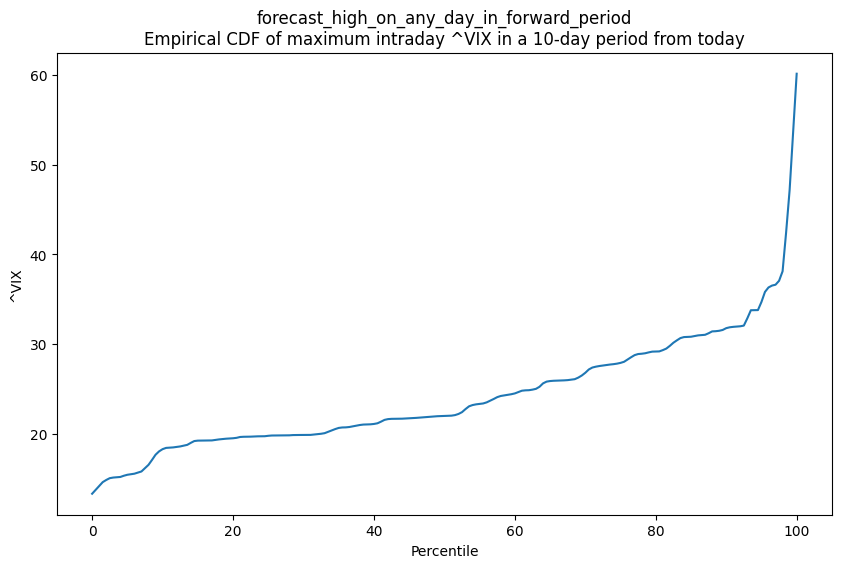

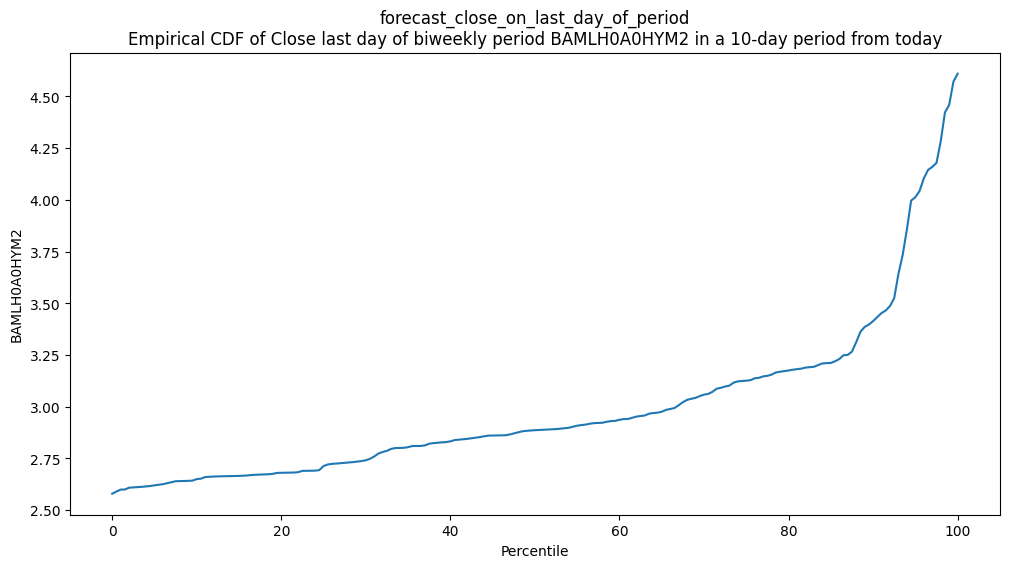

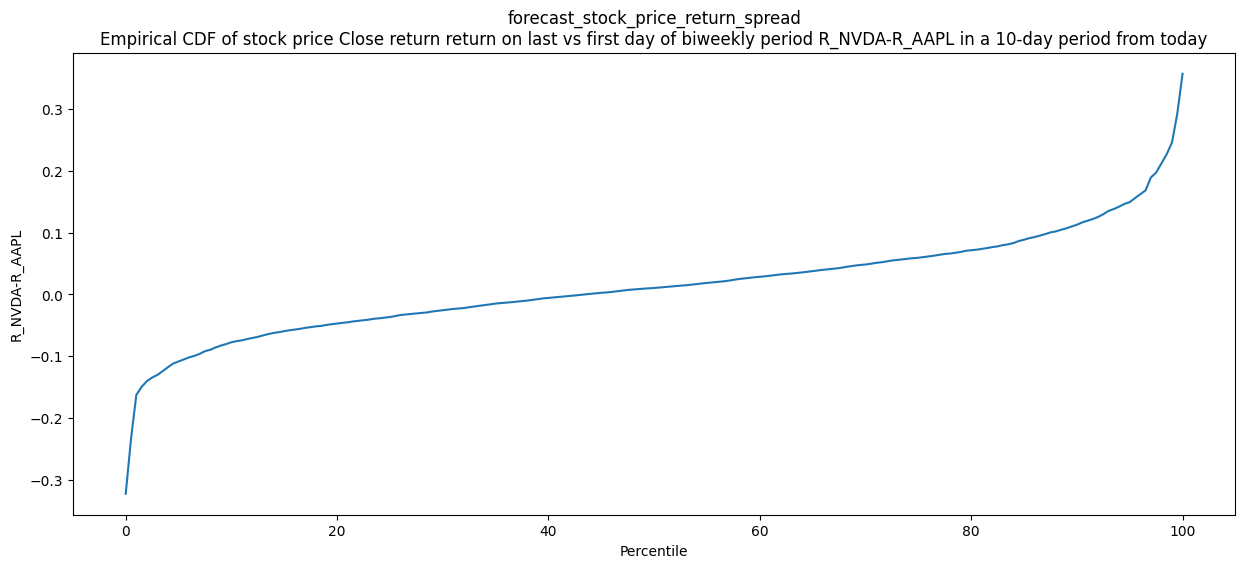

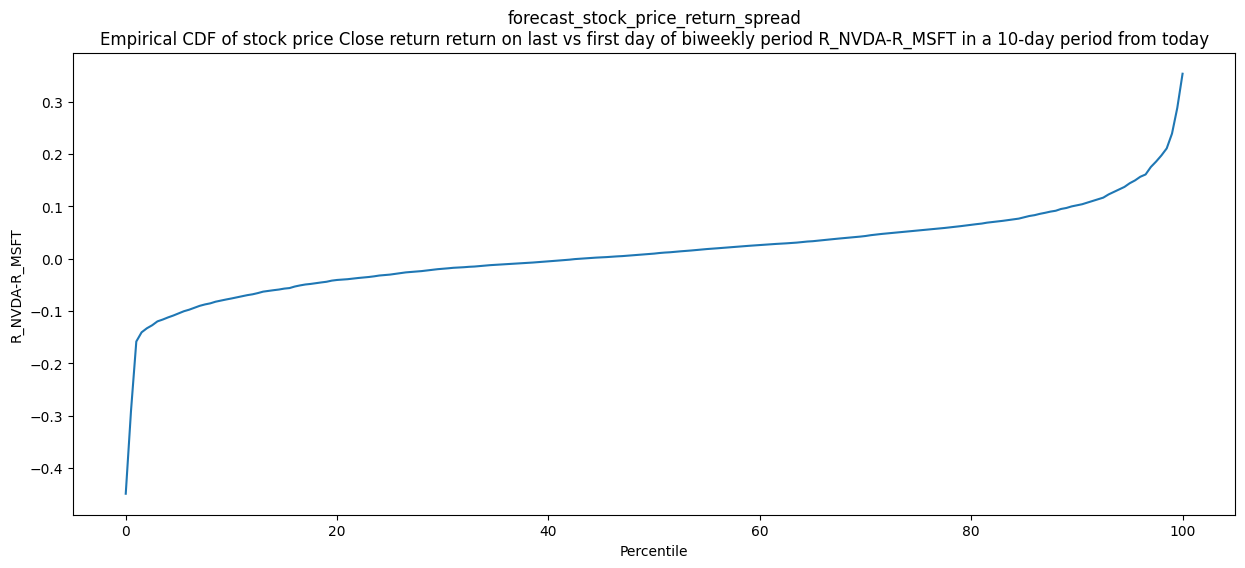

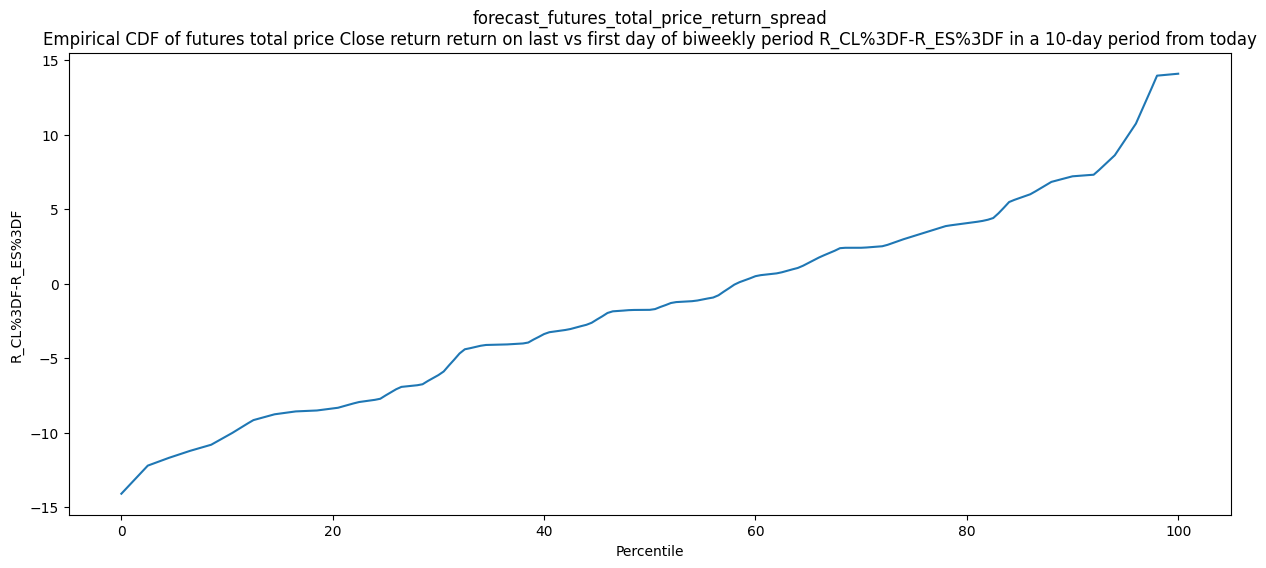

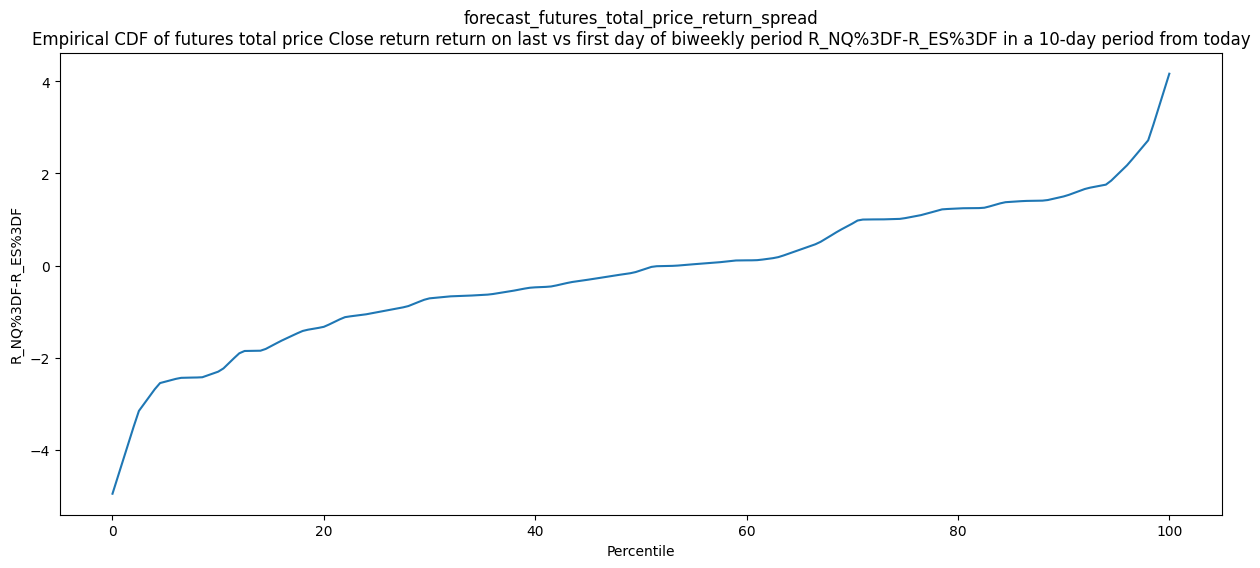

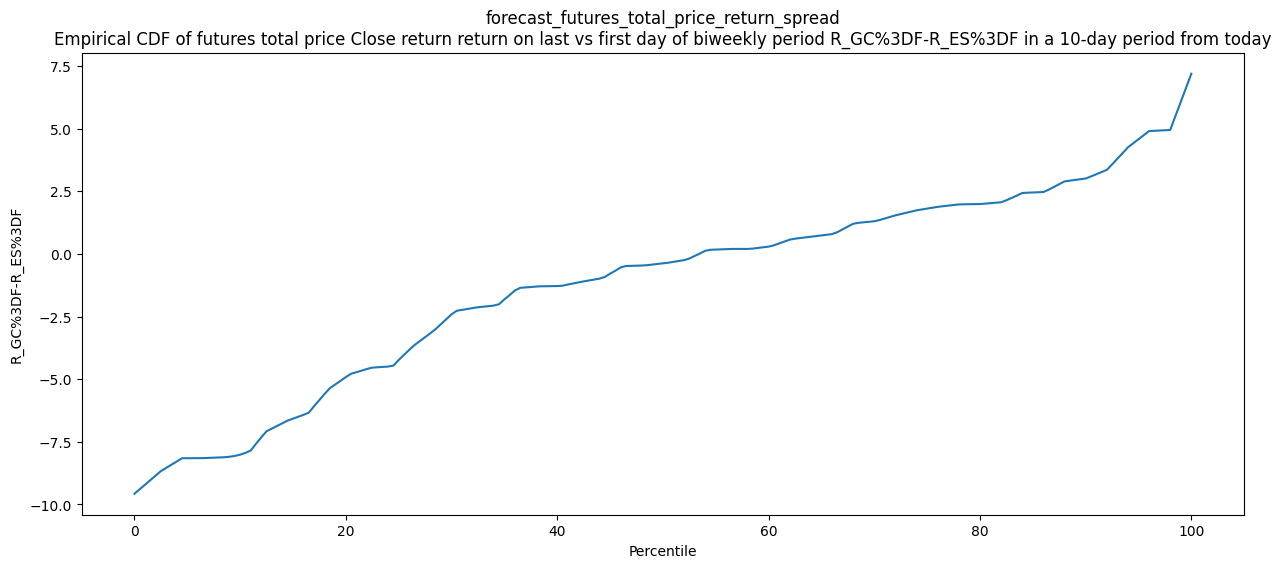

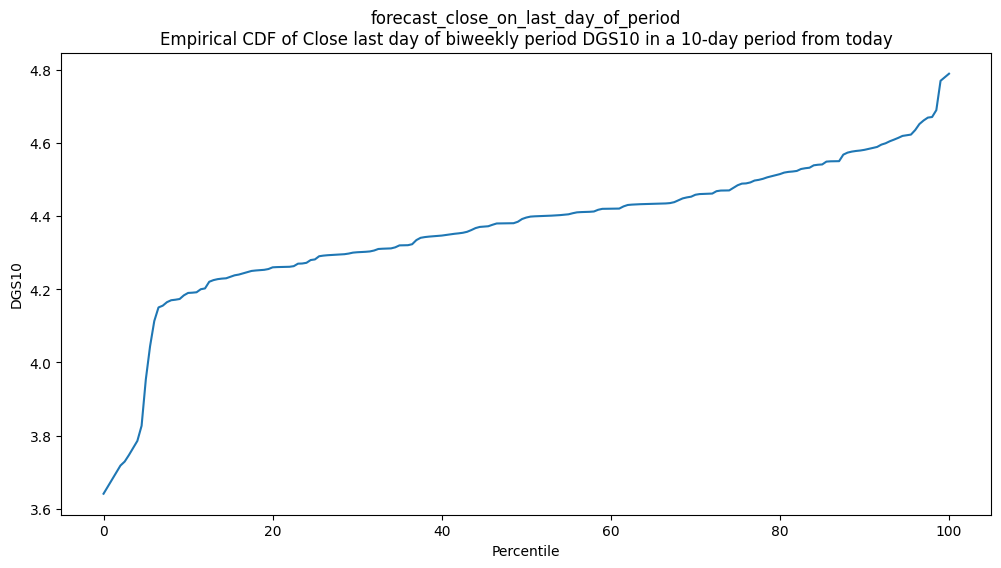

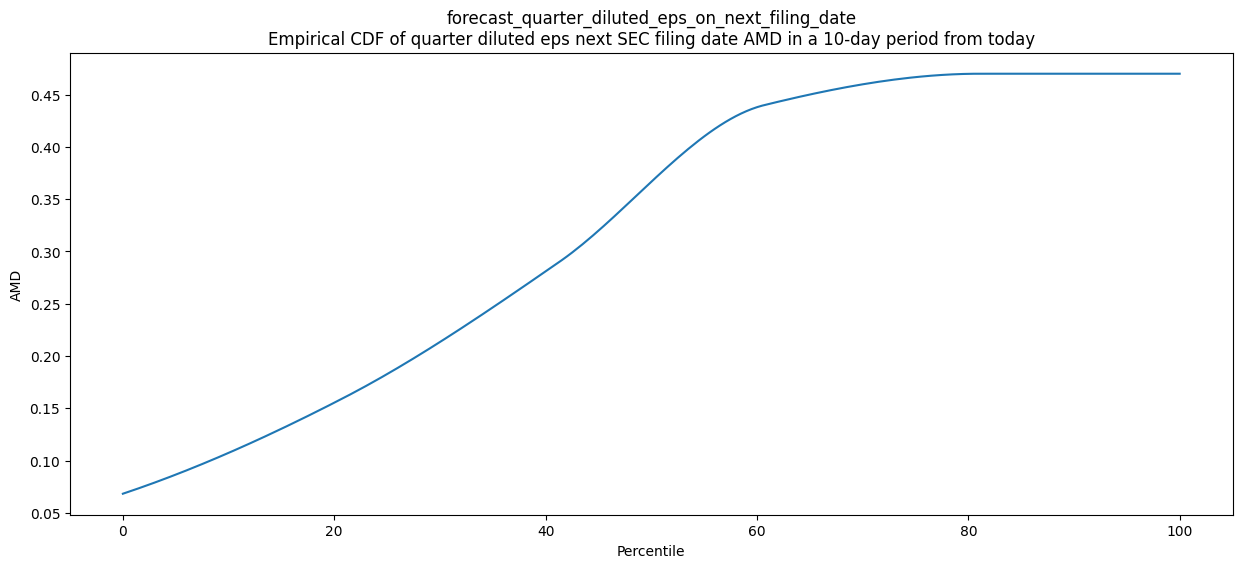

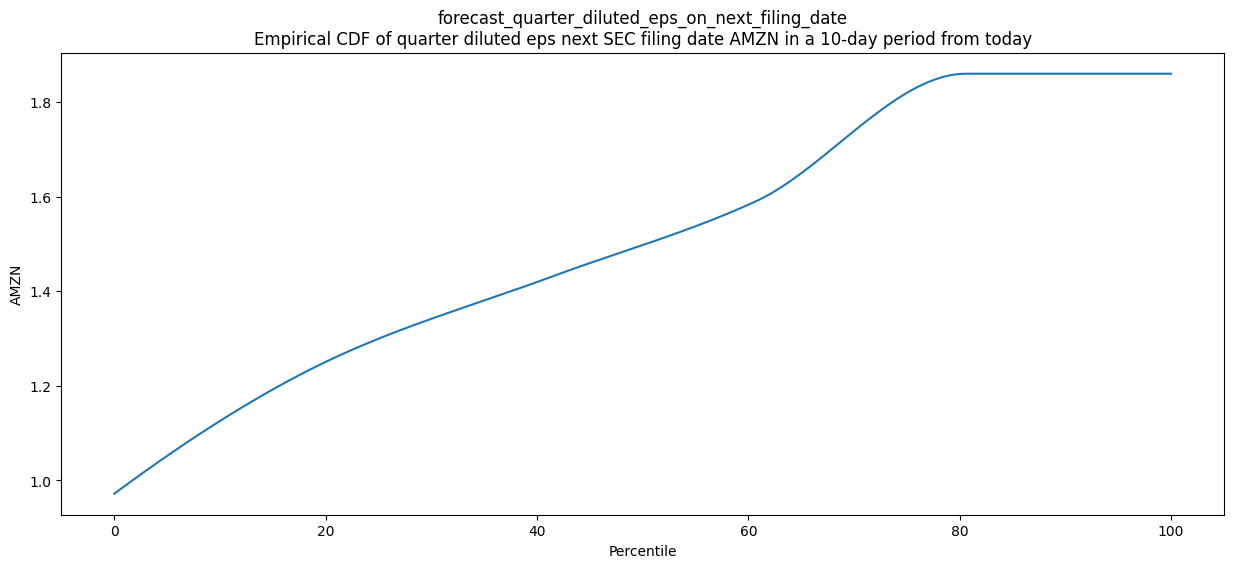

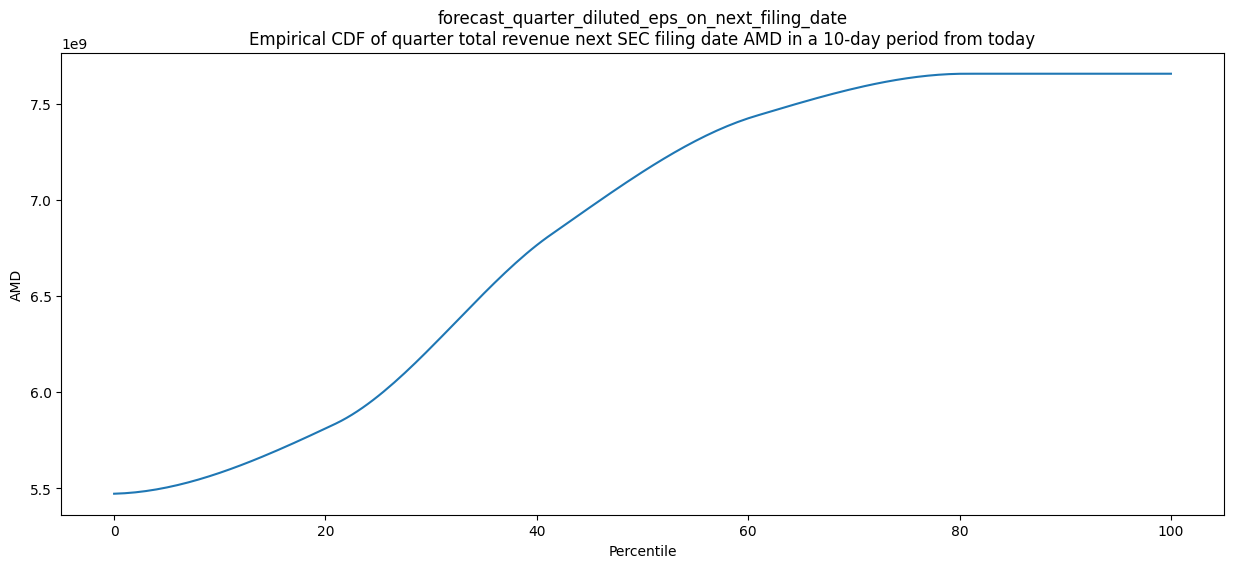

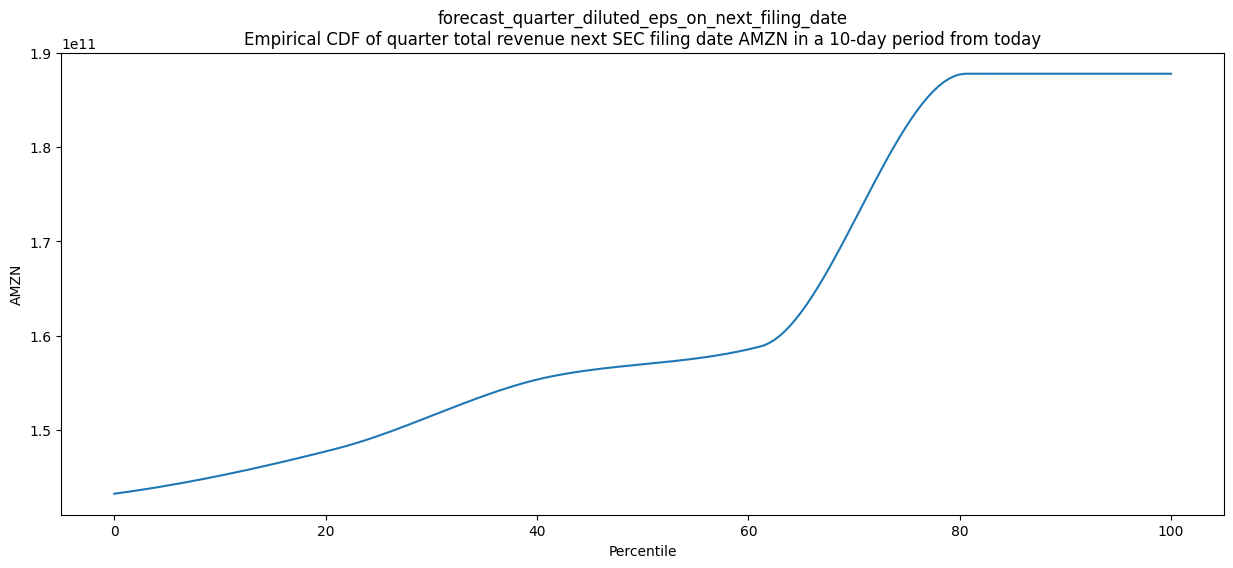

In [41]:
for i, ifp in enumerate(ifps):
    fn = forecast_fn(ifp)
    if not os.path.exists(fn):
        print(f"[{i}] {ifp['id']} {ifp['title']}")
        rng, prediction = forecast_glimt_ifp(ifp)
        ifp['prediction'] = prediction
        print(i, ifp['id'], ifp['type'], str(ifp['prediction'])[0:100])

In [42]:
ifp['prediction']

array([1.43236897e+11, 1.43313000e+11, 1.43391366e+11, 1.43471963e+11,
       1.43554758e+11, 1.43639719e+11, 1.43726812e+11, 1.43816005e+11,
       1.43907265e+11, 1.44000560e+11, 1.44095856e+11, 1.44193121e+11,
       1.44292322e+11, 1.44393427e+11, 1.44496402e+11, 1.44601215e+11,
       1.44707833e+11, 1.44816223e+11, 1.44926353e+11, 1.45038190e+11,
       1.45151701e+11, 1.45266853e+11, 1.45383614e+11, 1.45501950e+11,
       1.45621830e+11, 1.45743220e+11, 1.45866088e+11, 1.45990400e+11,
       1.46116125e+11, 1.46243229e+11, 1.46371679e+11, 1.46501444e+11,
       1.46632489e+11, 1.46764783e+11, 1.46898292e+11, 1.47032984e+11,
       1.47168827e+11, 1.47305786e+11, 1.47443830e+11, 1.47582926e+11,
       1.47723041e+11, 1.47864142e+11, 1.48006350e+11, 1.48154363e+11,
       1.48310085e+11, 1.48473078e+11, 1.48642902e+11, 1.48819117e+11,
       1.49001285e+11, 1.49188965e+11, 1.49381718e+11, 1.49579105e+11,
       1.49780686e+11, 1.49986022e+11, 1.50194673e+11, 1.50406200e+11,
      

In [44]:
for i, ifp in enumerate(ifps):
    print(i, ifp['id'], ifp['type'], str(ifp['prediction'])[0:50])

0 37913 binary 0.64
1 37915 binary 0.365
2 37916 binary 0.4
3 38340 numeric [13.36005007 13.78999996 14.21995284 14.64869242 1
4 38339 numeric [2.57965306 2.59       2.59960383 2.60000997 2.608
5 38345 numeric [-0.32226841 -0.23331643 -0.16252338 -0.14945778 -
6 38344 numeric [-4.48836586e-01 -2.89830515e-01 -1.58006953e-01 -
7 38343 numeric [-14.10416559 -13.72612475 -13.34808392 -12.970043
8 38341 numeric [-4.95450907e+00 -4.59099174e+00 -4.22747442e+00 -
9 38342 numeric [-9.57509416 -9.39438777 -9.21368137 -9.03297498 -
10 38338 numeric [3.64070352 3.66       3.67929648 3.6985935  3.717
11 38166 numeric [0.06829836 0.07       0.07173005 0.07348817 0.075
12 38267 numeric [0.97176344 0.98       0.98818662 0.99632212 1.004
13 38170 numeric [5.47202519e+09 5.47300000e+09 5.47452127e+09 5.47
14 38266 numeric [1.43236897e+11 1.43313000e+11 1.43391366e+11 1.43


In [45]:
for i, ifp in enumerate(ifps):
    row = pd.Series()
    row['forecast_date'] = today
    row['platform'] = 'MPC25Q3'
    row['id_of_question'] = ifp['id']
    fn = forecast_fn(row)
    if os.path.exists(fn):
        continue
    row['id_of_post'] = ifp['post_id']
    row['question_type'] = ifp['type']
    row['forecast'] = ifp['forecast']
    if ifp['type'] == 'numeric':
        p1 = ifp['prediction']
        p1[0] = ifp['scaling']['range_min']
        p1[-1] = ifp['scaling']['range_max']
        p1 = ensure_min_increase(p1)
        p2 = dict(zip(rng,p1))
        p4 = metaculus_generate_continuous_cdf(p2, ifp)
        p5 = standardize_cdf(p4, ifp['scaling'])
        row['prediction'] = p5
        ifp['cdf'] = p5
    elif ifp['type'] == 'binary':
        continue # already posted
    else:
        raise Exception(ifp['type'])

    post_group_forecast(row)

Prediction Post status code: 201
Posted forecast for 38340
Prediction Post status code: 201
Posted forecast for 38339
Prediction Post status code: 201
Posted forecast for 38345
Prediction Post status code: 201
Posted forecast for 38344
Prediction Post status code: 201
Posted forecast for 38343
Prediction Post status code: 201
Posted forecast for 38341
Prediction Post status code: 201
Posted forecast for 38342
Prediction Post status code: 201
Posted forecast for 38338
Prediction Post status code: 201
Posted forecast for 38166
Prediction Post status code: 201
Posted forecast for 38267
Prediction Post status code: 201
Posted forecast for 38170
Prediction Post status code: 201
Posted forecast for 38266


## Crowd alignment

In [46]:
from normalized_cdf_distance import normalized_cdf_distance

In [49]:
import numpy as np
import pandas as pd
rows = []
for ifp in ifps:
    forecast = [ifp['prediction'], 1-ifp['prediction']] if ifp['type'] == 'binary' else ifp['cdf']
    try:
        crowd = ifp['aggregations']['recency_weighted']['latest']['forecast_values']
    except:
        print('no crowd for', ifp['id'])
        continue
    distance = None
    if ifp['type'] == 'binary':
        distance = abs(forecast[0]-crowd[0])
    else:
        distance = normalized_cdf_distance(forecast, crowd)
    rows.append((ifp['id'], ifp['title'], distance))
df = pd.DataFrame(rows, columns = ('id', 'title', 'distance')).sort_values(by='distance')

no crowd for 38340
no crowd for 38339
no crowd for 38345
no crowd for 38344
no crowd for 38343
no crowd for 38341
no crowd for 38342
no crowd for 38338


In [50]:
df

,id,title,distance
4,38267,What will the first reported earnings per share after June 2025 be for the following companies? (AMZN),0.057024
0,37913,Will the following companies be added to the S&P 500 before October 2025? (ARES),0.060000
5,38170,What will the first reported revenues after June 2025 be for the following companies? (AMD),0.155077
3,38166,What will the first reported earnings per share after June 2025 be for the following companies? (AMD),0.170290
6,38266,What will the first reported revenues after June 2025 be for the following companies? (AMZN),0.195804
1,37915,Will the following companies be added to the S&P 500 before October 2025? (HOOD),0.405000
2,37916,Will the following companies be added to the S&P 500 before October 2025? (MSTR),0.540000


In [ ]:
df.distance.hist(bins=20)